# LC11 — Trees, forests and boosting: how the winning models work (self-paced, ~45 min)

LC10's two learners beat persistence by 50 MW — gradient boosting within 2 MW of the linear model on that table, and ahead of it once the split is stricter (LC12). Before anyone uses a model that wins, they should know **how** it wins and **how** it fails. This notebook opens the box: one decision tree, its overfitting disease, and the two cures — averaging (forests) and correcting (boosting). Material appears in **Quiz 4**.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a note above it saying what it is for and what you should see; the numbers quoted are the ones the course series produces. If what you see differs, stop and ask your pod.

## 0. Before you start: opening the notebook on your laptop

Local, not Colab — it reads the course dataset from the repository. From a terminal with your workbook's venv active (the Lab 1 one; `scikit-learn` is in it):

```bash
pip install jupyterlab            # once; the toolbox never imports it, so it is not in requirements.txt
cd <path to your clone of>/course-material/notebooks
jupyter lab                       # opens in your browser; double-click LC11_trees_boosting.ipynb
```

Start Jupyter *inside* `notebooks/` — the guard cell checks that. Shift+Enter runs a cell; the kernel offered, "Python 3 (ipykernel)", is your venv's Python when Jupyter was started from the activated venv. The whole notebook runs in well under a minute.

### 0.1 Setup

`%pip install` installs into the notebook's own Python; in the course venv everything is already there at its pinned version. **What you see:** one "Note: you may need to restart the kernel…" line, or nothing.

In [1]:
# Install exactly what this notebook uses.
%pip install scikit-learn pandas numpy pyarrow matplotlib --quiet


Note: you may need to restart the kernel to use updated packages.


The guard: `assert` stops here with a clear message if `../data` is missing. **What you see:** nothing — good.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

### 0.2 The same table as LC10

Exactly LC10's section 1.1, so the numbers here are comparable to that table: two lags, temperature, the clock as sine and cosine, weekday and workday, target, and the temporal split at 1 October. **What you see:** the list of the seven feature names.

In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
df = pd.read_parquet("../data/svedala-year/svedala_hourly.parquet")
y = df["ZON_MITT"].interpolate(limit=3)
X = pd.DataFrame(index=df.index)                 # the LC10 feature table, rebuilt line for line
X["lag24"], X["lag168"] = y.shift(24), y.shift(168)
X["temp"] = df["temp_mid"].interpolate(limit=3)
X["hour_sin"] = np.sin(2*np.pi*df.index.hour/24); X["hour_cos"] = np.cos(2*np.pi*df.index.hour/24)
X["dow"] = df.index.dayofweek; X["workday"] = (X["dow"] < 5).astype(int)
data = X.join(y.rename("target")).dropna()
train = data.loc[:"2025-09-30"]; test = data.loc["2025-10-01":]
Xtr, ytr = train.drop(columns="target"), train["target"]
Xte, yte = test.drop(columns="target"), test["target"]
print(f"features: {list(Xtr.columns)}")

features: ['lag24', 'lag168', 'temp', 'hour_sin', 'hour_cos', 'dow', 'workday']


## 1. One tree — readable, and that is the point

A depth-3 tree is a flowchart a human can audit. Read the splits: the tree *rediscovers* what you know about load — yesterday's value first, then temperature, then time of week:

### 1.1 Grow one shallow tree and read it

`DecisionTreeRegressor(max_depth=3)` grows a tree of at most three yes/no questions from root to leaf; `.fit(Xtr, ytr)` chooses the questions — at each node the feature and the threshold that split the training rows into the two most different groups. `plot_tree(t3, feature_names=...)` draws it: each box shows the question (`lag24 <= 3812.5` style), how many training rows reached it (`samples`), and the prediction a leaf makes (`value`, the mean load of its rows). **What you see:** a flowchart eight leaves wide. The root asks about `lag24`; the next levels ask about `lag24` again and about `temp` — the tree rediscovers what you know about load without being told.

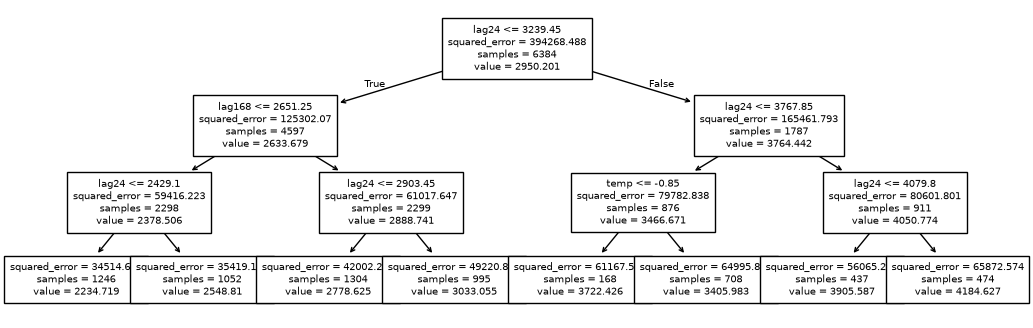

In [4]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
t3 = DecisionTreeRegressor(max_depth=3, random_state=0).fit(Xtr, ytr)
plt.figure(figsize=(13, 4)); plot_tree(t3, feature_names=list(Xtr.columns), fontsize=7, filled=False);

## 2. The disease: a tree memorizes

Let the depth grow and watch train error fall toward zero while test error turns around — the textbook overfitting curve, on real data:

### 2.1 The overfitting experiment

The loop fits one tree per depth (`None` means no limit at all) and records two errors: on the rows it was trained on and on the untouched October rows. `pd.DataFrame(rows).set_index("depth")` turns the list of dictionaries into a table (the Lab 2 idiom); `.plot()` draws both columns against depth. The eight fits take a few seconds.

**What you see:**

```
       train_MAE  test_MAE
depth
2          200.7     242.5
3          166.9     209.7
4          146.6     187.8
6          113.7     171.8
8           89.9     164.9
12          40.0     183.4
16           8.3     196.1
None         0.0     198.1
```

Train error falls to exactly zero — the unlimited tree has memorised every training hour — while test error bottoms out at depth 8 (164.9 MW) and climbs again. That turn is overfitting, on real data, in one table.

       train_MAE  test_MAE
depth                     
2          200.7     242.5
3          166.9     209.7
4          146.6     187.8
6          113.7     171.8
8           89.9     164.9
12          40.0     183.4
16           8.3     196.1
None         0.0     198.1


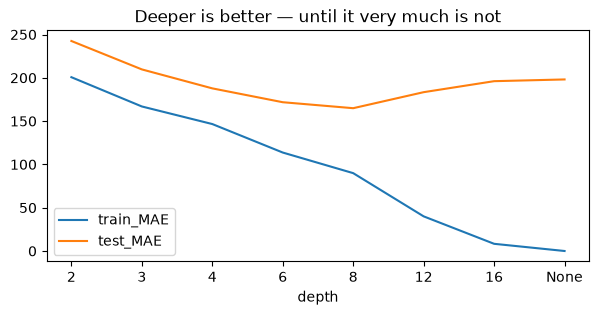

In [5]:
# The overfitting experiment: same data, growing depth (None = unlimited).
# For each depth, record TRAIN error (falls forever) and TEST error (turns).
depths = [2, 3, 4, 6, 8, 12, 16, None]
rows = []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=0).fit(Xtr, ytr)
    rows.append({"depth": str(d), "train_MAE": np.abs(m.predict(Xtr)-ytr).mean(),
                 "test_MAE": np.abs(m.predict(Xte)-yte).mean()})
res = pd.DataFrame(rows).set_index("depth").round(1)
print(res.to_string())
res.plot(figsize=(7,3), title="Deeper is better — until it very much is not");

## 3. Two cures

**Forest** (bagging): train many deep trees on random subsets, average away their individual nonsense. **Boosting**: train shallow trees *in sequence*, each one fitted to the errors of the sum so far. Different philosophies, both tame the variance:

### 3.1 Forest and boosting, one line each

`comp` starts with the best single tree from the table above (`res["test_MAE"].astype(float).min()` — the column was rounded to text-like floats, `astype(float)` makes it numeric again). `RandomForestRegressor(n_estimators=100, n_jobs=-1)` grows 100 deep trees, each on a random subset of rows and features, and averages their predictions (`n_jobs=-1` uses every CPU core; this is the slowest cell, a few seconds). `HistGradientBoostingRegressor` is LC10's boosting model: shallow trees fitted one after another, each to the errors the previous ones left.

**What you see:**

```
single tree (best depth)    164.9
random forest               143.2
gradient boosting           130.8
```

Both cures beat the best single tree; boosting wins here by 12 MW, and `130.8` is the number LC10's table showed for the same model.

In [6]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
comp = {"single tree (best depth)": res["test_MAE"].astype(float).min()}
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=0).fit(Xtr, ytr)
comp["random forest"] = np.abs(rf.predict(Xte)-yte).mean()
gb = HistGradientBoostingRegressor(random_state=0).fit(Xtr, ytr)
comp["gradient boosting"] = np.abs(gb.predict(Xte)-yte).mean()
print(pd.Series(comp).round(1).to_string())

single tree (best depth)    164.9
random forest               143.2
gradient boosting           130.8


## 4. Feature importance — useful, and routinely over-read

Every applied ML talk shows an importance bar chart. Two caveats before you ever put one in a report: importances split credit arbitrarily between **correlated features** (lag24 and lag168 share the same signal), and importance is **not causality** — temperature "mattering" does not tell an operator what happens if they could change it:

### 4.1 The bar chart everyone shows

`rf.feature_importances_` is a number per feature saying how much of the forest's splitting work that feature did, summing to 1; `pd.Series(..., index=Xtr.columns).sort_values()` names and orders them, `.plot.barh` draws horizontal bars. **What you see:** `lag24` at about 0.79, `lag168` at 0.15, everything else under 0.03. Read it with both caveats: `lag24` and `lag168` carry much of the same signal, so the split of credit between them is arbitrary; and a small bar for `temp` does not mean temperature does not matter — the lags already carry yesterday's weather.

workday     0.003
hour_sin    0.007
hour_cos    0.008
dow         0.022
temp        0.027
lag168      0.146
lag24       0.787


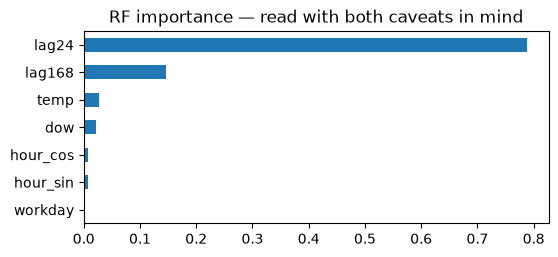

In [7]:
imp = pd.Series(rf.feature_importances_, index=Xtr.columns).sort_values()
imp.plot.barh(figsize=(6,2.5), title="RF importance — read with both caveats in mind");
print(imp.round(3).to_string())

## Self-check

Two promises: boosting beats the best single tree, and the unlimited tree's training error is under 5 MW (it memorised). **What you see:** `ALL OK — you know how the winner wins. Lab 8 points the same models at N-1 security.`

In [8]:
best_single = res["test_MAE"].astype(float).min()
assert comp["gradient boosting"] < best_single, "boosting should beat any single tree"
assert res["train_MAE"].astype(float).iloc[-1] < 5, "unlimited tree should near-memorize the train set"
print("ALL OK — you know how the winner wins. Lab 8 points the same models at N-1 security.")

ALL OK — you know how the winner wins. Lab 8 points the same models at N-1 security.


## 5. What you take to Lab 8

Lab 8 uses the classifier twins of these models — `DecisionTreeClassifier`, `HistGradientBoostingClassifier` — on a table where the target is a yes/no (*is this hour N-1 secure?*) instead of a number. The lessons carry over unchanged: a shallow tree you can read, a deep tree that memorises, an ensemble that generalises, and an importance chart to read with care. What changes is the metric — accuracy is the wrong headline for an imbalanced yes/no, which is the whole point of that lab.